In [1]:
#import libraries
import numpy as np
import cv2
from PIL import Image
import os
import PIL
import glob
# from Main_program import imageFilename

imageFileName = input("enter the name of the image file: ") #enter complete path of the image for which the size has to be found

fixed_height = 400
image = Image.open(imageFileName)
height_percent = (fixed_height / float(image.size[1]))
width_size = int((float(image.size[0]) * float(height_percent)))
image = image.resize((width_size, fixed_height), PIL.Image.NEAREST)
image.save('resized_front.jpg')

enter the name of the image file: Front image/woman7.png


In [2]:
#import libraries
#import matplotlib.pyplot as plt

#read input image
#imgfilename=input("Enter path of the image:")
img = cv2.imread('resized_front.jpg')
cv2.imshow('Image', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

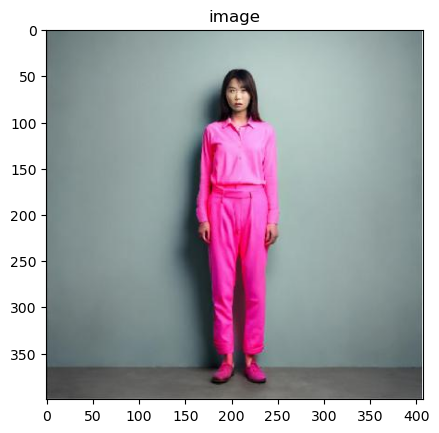

In [3]:
from matplotlib import pyplot as plt #import matplotlib

img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #convert colour from BGR to RGB
plt.imshow(img)
plt.title('image')
plt.axis('on')
plt.show()

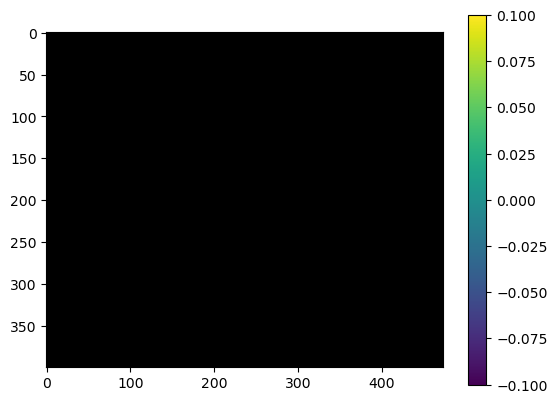

In [8]:
from PIL import Image
import os
import PIL
import glob

# define mask
mask = np.zeros(img.shape[:2],np.uint8)
bgdModel = np.zeros((1,65),np.float64)
fgdModel = np.zeros((1,65),np.float64)

# define rectangle left, top, width, height
rect = (100,130,100,350)

# apply grabCut method to extract the foreground
cv2.grabCut(img,mask,rect,bgdModel,fgdModel,20,cv2.GC_INIT_WITH_RECT)
mask2 = np.where((mask==2)|(mask==0),0,1).astype('uint8')
img = img*mask2[:,:,np.newaxis]
cv2.imwrite('newimage.jpg',img)
# display the extracted foreground image

plt.imshow(img),plt.colorbar(),plt.show()
cv2.imshow('Foreground Image',img)
cv2.waitKey(0)
cv2.destroyAllWindows()